In [1]:
import numpy as np
from parameters import get_parameters, get_slider_params, calculate_derived_parameters
from model_run import run_model_dash
from global_func import reset_flags, reset_E, reset_HSS, reset_S
import math
import matplotlib.pyplot as plt
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

In [2]:
total_runs = 100
seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=total_runs)
MODEL = {
    "int_period": 36,
    "n_months": 36,
}
slider_params = get_slider_params()
results = []
for run in range(total_runs):
    base_seed = seeds[run]
    rng_param = np.random.default_rng(base_seed)
    b_param = get_parameters(rng = rng_param)
    b_param = calculate_derived_parameters(b_param)
    b_flags = reset_flags()
    b_HSS = reset_HSS(slider_params)
    b_S = reset_S(slider_params)
    b_E = reset_E()
    b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS
    })
    n_months = MODEL["n_months"]
    int_period = MODEL["int_period"]
    _, outcomes = run_model_dash(b_param, b_flags, n_months, int_period, base_seed=base_seed)

    outcomes['i_facility'] = np.where(outcomes['i_loc_new_v2'] > 0, 1, 0)

    results.append({
        "p_aph_fac": outcomes.groupby('i_facility')['i_aph'].mean().get(1, 0),
        "p_uterine_fac": outcomes.groupby('i_facility')['i_ruptured_uterus'].mean().get(1, 0),
    })

    # Convert to DataFrame and compute mean
df_results = pd.DataFrame(results).mean().to_dict()
#round 2 digits for each cell of df_results
df_results = {k: round(v, 4) for k, v in df_results.items()}
df_results

{'p_aph_fac': 0.0181, 'p_uterine_fac': 0.0197}

In [2]:
# Define the parameter space for Bayesian Optimization
param_space = [
    Real(0.015, 0.025,    name='p_aph'),
    Real(0.015, 0.025,    name='p_ruptured_uterus'),
]

# Calibration target values
target_values = {
    "p_aph_fac": 0.018,
    "p_uterine_fac": 0.0197,
}

# Generate unique seeds for reproducibility
total_runs = 100
seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=total_runs)

# Objective function for Bayesian Optimization
@use_named_args(param_space)
def objective(**params):

    from parameters import get_parameters, get_slider_params
    from model_run import run_model_dash
    from global_func import reset_flags, reset_E, reset_HSS, reset_S

    MODEL = {
        "int_period": 36,
        "n_months": 36,
    }

    slider_params = get_slider_params()
    results = []

    for run in range(total_runs):
        base_seed = seeds[run]
        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S = reset_S(slider_params)
        b_E = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        # Replace parameters with those to calibrate
        b_param['p_aph'] = params['p_aph']
        b_param['p_ruptured_uterus'] = params['p_ruptured_uterus']

        #update parameters
        b_param = calculate_derived_parameters(b_param)

        #run the model
        n_months = MODEL["n_months"]
        int_period = MODEL["int_period"]
        _, outcomes = run_model_dash(b_param, b_flags, n_months, int_period, base_seed=base_seed)

        # Calculate outcomes
        outcomes['i_facility'] = np.where(outcomes['i_loc_new_v2'] > 0, 1, 0)

        results.append({
            "p_aph_fac": outcomes.groupby('i_facility')['i_aph'].mean().get(1, 0),
            "p_uterine_fac": outcomes.groupby('i_facility')['i_ruptured_uterus'].mean().get(1, 0),
        })

    # Convert to DataFrame and compute mean
    df_results = pd.DataFrame(results).mean().to_dict()

    # Add this line here for early stopping access
    objective.last_df_results = df_results

    # Compute relative RMSE
    relative_squared_errors = [ ((df_results[k] - target_values[k]) / target_values[k])**2 for k in target_values ]
    rmse = math.sqrt(sum(relative_squared_errors) / len(relative_squared_errors))

    # Print current evaluation
    print("\n--- Calibration Iteration ---")
    print("Parameters:")
    for k, v in params.items():
        print(f"  {k:22s}: {v:.4f}")

    print("\nTarget vs Simulated Outcomes:")
    for k in target_values:
        sim = df_results.get(k, 0)
        target = target_values[k]
        error = sim - target
        rel_error = error / target
        print(f"  {k:22s} | Simulated: {sim:.4f}, Target: {target:.4f}, Relative Error: {rel_error:+.2%}")


    print(f"\nRMSE Loss: {rmse:.6f}")
    print("-----------------------------\n")

    return rmse

In [3]:
# Track RMSE history
rmse_history = []

class EarlyStopper:
    def __init__(self, threshold_rmse=0.05, relative_threshold=0.05):
        self.threshold_rmse = threshold_rmse
        self.relative_threshold = relative_threshold
        self.best_loss = float('inf')
        self.call_count = 0
        self.best_params = None
        self.best_df_results = None

    def meets_relative_criteria(self, sim_results):
        for k in target_values:
            target = target_values[k]
            sim = sim_results.get(k, 0)
            rel_error = abs(sim - target) / target
            if rel_error > self.relative_threshold:
                return False
        return True

    def __call__(self, *args, **kwargs):
        loss = objective(*args, **kwargs)
        rmse_history.append(loss)

        self.call_count += 1
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_params = args[0] if args else None

        sim_results = getattr(objective, "last_df_results", {})
        if self.best_loss < self.threshold_rmse and self.meets_relative_criteria(sim_results):
            print(f"\n⏹️ Early stopping triggered. RMSE: {self.best_loss:.6f}")
            raise StopIteration

        return loss

def save_results(best_params, best_loss, rmse_history, param_space):
    param_names = [dim.name for dim in param_space]
    best_param_dict = dict(zip(param_names, best_params))
    best_param_dict["Best RMSE"] = best_loss
    df_best = pd.DataFrame([best_param_dict])
    df_best.to_csv("best_parameters_aph_rtuptured.csv", index=False)

    pd.DataFrame({"Iteration": range(1, len(rmse_history)+1), "RMSE": rmse_history}).to_csv("rmse_history_aph_rtuptured.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(rmse_history)+1), rmse_history, marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("RMSE Loss")
    plt.title("RMSE Loss Over Iterations")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("rmse_plot_aph_rtuptured.png")
    plt.close()

In [4]:
def optimize_model():
    early_stopper = EarlyStopper(threshold_rmse=0.05, relative_threshold=0.05)
    try:
        result = gp_minimize(
            func=early_stopper,
            dimensions=param_space,
            n_calls=100,
            random_state=42,
            n_random_starts=20,
            base_estimator="GP",   # Gaussian Process is ideal for 2D
            acq_func="EI",         # Expected improvement
            verbose=True
        )
        print("\n✅ Optimization completed.")
        print("Best Parameters:", result.x)
        print("Best Loss:", result.fun)
        save_results(result.x, result.fun, rmse_history, param_space)
        return result

    except StopIteration:
        print("\n✅ Optimization stopped early.")
        print(f"Best RMSE achieved: {early_stopper.best_loss:.6f}")
        if early_stopper.best_params is not None:
            print("Best Parameters:")
            for name, val in zip([d.name for d in param_space], early_stopper.best_params):
                print(f"  {name:22s}: {val:.4f}")
            save_results(early_stopper.best_params, early_stopper.best_loss, rmse_history, param_space)
        return None

# Run the optimization
if __name__ == "__main__":
    optimize_model()

Iteration No: 1 started. Evaluating function at random point.

--- Calibration Iteration ---
Parameters:
  p_aph                 : 0.0230
  p_ruptured_uterus     : 0.0168

Target vs Simulated Outcomes:
  p_aph_fac              | Simulated: 0.0236, Target: 0.0180, Relative Error: +31.04%
  p_uterine_fac          | Simulated: 0.0175, Target: 0.0197, Relative Error: -11.18%

RMSE Loss: 0.233279
-----------------------------

Iteration No: 1 ended. Evaluation done at random point.
Time taken: 89.2952
Function value obtained: 0.2333
Current minimum: 0.2333
Iteration No: 2 started. Evaluating function at random point.

--- Calibration Iteration ---
Parameters:
  p_aph                 : 0.0228
  p_ruptured_uterus     : 0.0210

Target vs Simulated Outcomes:
  p_aph_fac              | Simulated: 0.0234, Target: 0.0180, Relative Error: +30.09%
  p_uterine_fac          | Simulated: 0.0216, Target: 0.0197, Relative Error: +9.55%

RMSE Loss: 0.223194
-----------------------------

Iteration No: 2 e

In [ ]:
# --- Calibration Iteration ---
# Parameters:
#   p_aph                 : 0.0176
#   p_ruptured_uterus     : 0.0191
#
# Target vs Simulated Outcomes:
#   p_aph_fac              | Simulated: 0.0181, Target: 0.0180, Relative Error: +0.75%
#   p_uterine_fac          | Simulated: 0.0198, Target: 0.0197, Relative Error: +0.26%
#
# RMSE Loss: 0.005628
# -----------------------------
#
#
# ⏹️ Early stopping triggered. RMSE: 0.005628
#
# ✅ Optimization stopped early.
# Best RMSE achieved: 0.005628
# Best Parameters:
#   p_aph                 : 0.0176
#   p_ruptured_uterus     : 0.0191

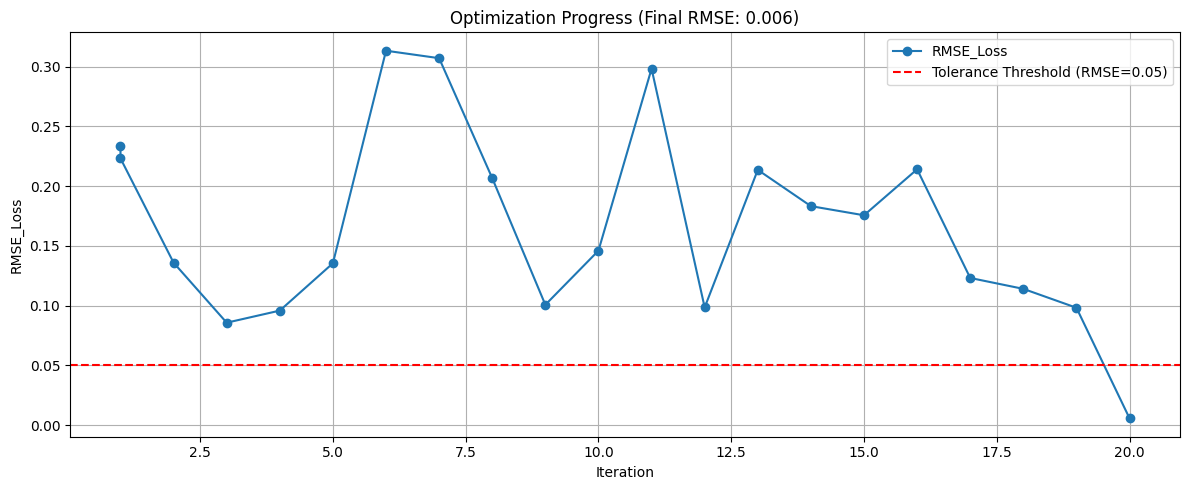

In [5]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV if needed
rmse_df = pd.read_csv("rmse_history_aph_ruptured.csv")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(rmse_df['Iteration'], rmse_df['RMSE_Loss'], marker='o', label='RMSE_Loss')
plt.axhline(y=0.05, color='red', linestyle='--', label='Tolerance Threshold (RMSE=0.05)')

# Add labels and title
final_rmse = rmse_df['RMSE_Loss'].iloc[-1]
plt.title(f"Optimization Progress (Final RMSE: {final_rmse:.3f})")
plt.xlabel("Iteration")
plt.ylabel("RMSE_Loss")
plt.legend()
plt.grid(True)

# Save the plot
plt.savefig("rmse_aph_ruptured.png", dpi=300)

# Show plot
plt.tight_layout()
plt.show()